In [4]:
import os
base_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
print(os.path.exists(os.path.join(base_dir, "GivenResources")))


True


solar_like | T=500K | A_H=13.444
solar_like | T=714K | A_H=15.170
solar_like | T=929K | A_H=16.350
solar_like | T=1143K | A_H=18.392
solar_like | T=1357K | A_H=20.057
solar_like | T=1571K | A_H=22.095
solar_like | T=1786K | A_H=24.660
solar_like | T=2000K | A_H=28.014
metal_rich | T=500K | A_H=22.450
metal_rich | T=714K | A_H=23.222
metal_rich | T=929K | A_H=24.133
metal_rich | T=1143K | A_H=25.671
metal_rich | T=1357K | A_H=27.679
metal_rich | T=1571K | A_H=29.968
metal_rich | T=1786K | A_H=32.600
metal_rich | T=2000K | A_H=35.654
water_dominated | T=500K | A_H=16.014
water_dominated | T=714K | A_H=15.743
water_dominated | T=929K | A_H=15.284
water_dominated | T=1143K | A_H=15.920
water_dominated | T=1357K | A_H=16.340
water_dominated | T=1571K | A_H=16.780
water_dominated | T=1786K | A_H=17.240
water_dominated | T=2000K | A_H=17.723


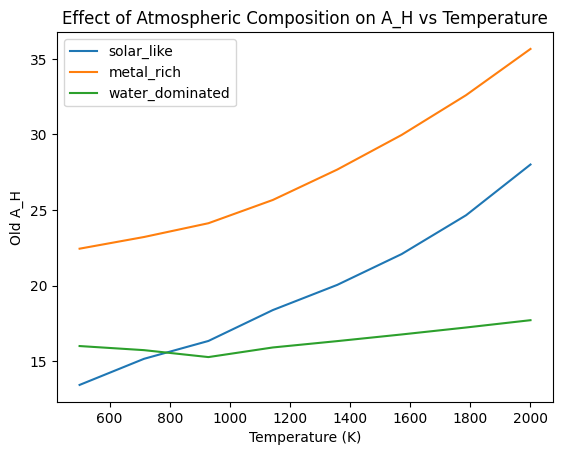

Elapsed time: 1.0691149234771729 seconds


In [11]:
import numpy as np
import scipy.constants as sc
from scipy.interpolate import RegularGridInterpolator
import astropy.constants as const
import matplotlib.pyplot as plt
import os
import time

# ===============================
# 1. Load Cross-Sections (once)
# ===============================

def load_cross_sections():

    base_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))


    xsec_path = os.path.join(
        base_dir,
        'GivenResources',
        'cross_section_files',
        'Cross_section_files'
    )

    molecules = ['h2o', 'ch4', 'co', 'co2']

    xsec_dict = {}
    lam_dict = {}
    P_dict = {}
    T_dict = {}

    for mol in molecules:
        xsec_dict[mol] = np.load(os.path.join(xsec_path, f'{mol}_xsec.npy'))
        lam_dict[mol] = np.load(os.path.join(xsec_path, f'{mol}_lam.npy')) * 1e6
        P_dict[mol] = 10**np.load(os.path.join(xsec_path, f'{mol}_P.npy'))
        T_dict[mol] = np.load(os.path.join(xsec_path, f'{mol}_T.npy'))

    xsec_h2h2 = np.load(os.path.join(xsec_path, 'h2_h2_xsec.npy'))
    lam_h2h2 = np.load(os.path.join(xsec_path, 'h2_h2_lam.npy'))

    xsec_heh2 = np.load(os.path.join(xsec_path, 'he_h2_xsec.npy'))
    lam_heh2 = np.load(os.path.join(xsec_path, 'he_h2_lam.npy'))

    return xsec_dict, lam_dict, P_dict, T_dict, xsec_h2h2, lam_h2h2, xsec_heh2, lam_heh2



# ===============================
# 2. Composition Definitions
# ===============================

def get_composition(comp_type):

    if comp_type == "solar_like":
        logX = {'h2o': -3.0, 'ch4': -5.0, 'co': -4.0, 'co2': -6.0}

    elif comp_type == "metal_rich":
        logX = {'h2o': -1.1, 'ch4': -1.74, 'co': -2.0, 'co2': -1.7}

    elif comp_type == "water_dominated":
        logX = {'h2o': -0.3, 'ch4': -6.0, 'co': -6.0, 'co2': -6.0}

    return logX


# ===============================
# 3. Mean Molecular Weight
# ===============================

def compute_mu(logX):

    mmw = {
        'h2o': 18.0,
        'ch4': 16.0,
        'co': 28.0,
        'co2': 44.0,
        'h2': 2.0,
        'he': 4.0
    }

    X_rest = np.sum([10**logX[m] for m in logX])
    X_H2 = (1.0 - X_rest) / (1.0 + 0.17)
    X_He = 0.17 * X_H2

    logX['h2'] = np.log10(X_H2)
    logX['he'] = np.log10(X_He)

    mu = 0.0
    for mol in logX:
        mu += 10**logX[mol] * mmw[mol]

    return mu * sc.u, logX


# ===============================
# 4. Atmosphere Builder
# ===============================

def build_atmosphere(Tp, mu, Rp, Mp, Pref):

    P = np.logspace(2.0, -9, 100) * 1e5
    T = Tp * np.ones_like(P)

    gp = (sc.G * Mp) / (Rp)**2

    r = np.zeros_like(P)
    g = np.zeros_like(P)

    i_Rp = np.argmin(np.abs(P - Pref))
    r[i_Rp] = Rp
    g[i_Rp] = gp

    for i in range(i_Rp + 1, len(P)):
        g[i] = g[i_Rp] * r[i_Rp]**2 / r[i-1]**2
        H_local = sc.k * Tp / (mu * g[i])
        delta_r = H_local * np.log(P[i-1] / P[i])
        delta_r = np.clip(delta_r, -5e6, 5e6)
        r[i] = r[i-1] + delta_r
        # if r[i] > Rp * 1.5:
        #     r[i] = Rp * 1.5


    for i in range(i_Rp - 1, -1, -1):
        g[i] = g[i_Rp] * r[i_Rp]**2 / r[i+1]**2
        H_local = sc.k * Tp / (mu * g[i])
        delta_r = H_local * np.log(P[i+1] / P[i])
        delta_r = np.clip(delta_r, -5e6, 5e6)
        r[i] = r[i+1] + delta_r
        # if r[i] > Rp * 1.5:
        #     r[i] = Rp * 1.5


    n = P / (sc.k * T)

    return P, T, r, g, gp, n


# ===============================
# 5. Transmission Spectrum
# ===============================

def compute_transmission_spectrum(
        Tp, logX, Rp, Rs, P, T, r, n,
        xsec_dict, lam_dict, P_dict, T_dict,
        xsec_h2h2, lam_h2h2,
        xsec_heh2, lam_heh2):

    lam = np.linspace(0.61, 5.0, 200)

    log_xsec_dict = {}

    for mol in ['h2o', 'ch4', 'co', 'co2']:

        interp = RegularGridInterpolator(
            (lam_dict[mol], P_dict[mol], T_dict[mol]),
            xsec_dict[mol],
            bounds_error=False,
            fill_value=None
        )

        lamlam, PP = np.meshgrid(lam, P, indexing="ij")
        T0 = np.clip(T[0], T_dict[mol].min(), T_dict[mol].max())
        pts = np.vstack((lamlam.ravel(), PP.ravel(), np.full(lamlam.size, T0))).T

        log_xsec_dict[mol] = interp(pts).reshape(lamlam.shape)

    log_cia_h2h2 = np.interp(lam, lam_h2h2, xsec_h2h2)
    log_cia_heh2 = np.interp(lam, lam_heh2, xsec_heh2)

    sum_nsigma = np.zeros((len(lam), len(P)))

    for mol in log_xsec_dict:
        sum_nsigma += n[np.newaxis, :] * 10**logX[mol] * 10**log_xsec_dict[mol]

    sum_nsigma += n[np.newaxis,:]**2 * 10**logX['h2']**2 * 10**log_cia_h2h2[:,None]
    sum_nsigma += n[np.newaxis,:]**2 * 10**logX['he'] * 10**logX['h2'] * 10**log_cia_heh2[:,None]

    integral_gt_Rp = np.zeros(len(lam))
    integral_lt_Rp = np.zeros(len(lam))
    exptau = np.zeros((len(P), len(lam)))

    for i in range(len(r)-1):

        s_tot = np.sqrt(r[i:]**2 - r[i]**2)
        ds = s_tot[1:] - s_tot[:-1]

        tau = np.sum((sum_nsigma[:, i:-1] + sum_nsigma[:, i+1:]) * ds[np.newaxis,:], axis=-1)
        exptau[i, :] = np.exp(-tau) + 1e-250

    for i in range(len(r)-1):

        if r[i] >= Rp:
            integral_gt_Rp += 0.5*((r[i]*(1-exptau[i]) +
                                    r[i+1]*(1-exptau[i+1]))*(r[i+1]-r[i]))

        if r[i] < Rp:
            integral_lt_Rp += 0.5*((r[i]*exptau[i] +
                                    r[i+1]*exptau[i+1])*(r[i+1]-r[i]))

    transit_depth = (Rp**2 + 2*integral_gt_Rp - 2*integral_lt_Rp)/(Rs**2)

    return lam, transit_depth


# ===============================
# 6. A_H Metric
# ===============================

def compute_AH(transit_depth, Tp, mu, Rp, Rs, gp):

    H = sc.k * Tp / (mu * gp)
    delta_D = np.max(transit_depth) - np.min(transit_depth)
    AH = delta_D / (2 * H * Rp / (Rs**2))

    return AH


# ===============================
# 7. Experiment Controller
# ===============================

def run_experiment():

    # Choose ONE planet manually for experiment - GJ 1214 b
    Rp = 2.733 * const.R_earth.value
    Mp = 8.41 * const.M_earth.value
    Rs = 0.2162 * const.R_sun.value 
    Pref = 1e5

    temperature_grid = np.linspace(500, 2000, 8)
    composition_types = ["solar_like", "metal_rich", "water_dominated"]

    xsec_data = load_cross_sections()

    AH_results = {c: [] for c in composition_types}

    for comp in composition_types:

        for Tp in temperature_grid:

            logX = get_composition(comp)
            mu, logX = compute_mu(logX)

            P, T, r, g, gp, n = build_atmosphere(Tp, mu, Rp, Mp, Pref)

            lam, transit_depth = compute_transmission_spectrum(
                Tp, logX, Rp, Rs, P, T, r, n,
                *xsec_data
            )

            AH = compute_AH(transit_depth, Tp, mu, Rp, Rs, gp)

            AH_results[comp].append(AH)

            print(f"{comp} | T={Tp:.0f}K | A_H={AH:.3f}")

    for comp in composition_types:
        plt.plot(temperature_grid, AH_results[comp], label=comp)

    plt.xlabel("Temperature (K)")
    plt.ylabel("Old A_H")
    plt.legend()
    plt.title("Effect of Atmospheric Composition on A_H vs Temperature")
    plt.show()


# ===============================
# MAIN
# ===============================

if __name__ == "__main__":
    start = time.time()
    run_experiment()
    print("Elapsed time:", time.time() - start, "seconds")
